# 🏎️ Formula 1 Race Outcome Prediction Using Machine Learning

### Author
Maham Ieman Malik

---

## Objective

The objective of this project is to build a machine learning model that predicts Formula 1 race outcomes using historical race and qualifying data.

This notebook covers:
- Data Exploration
- Data Cleaning
- Feature Engineering
- Machine Learning Model Training
- Model Evaluation

In [57]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [58]:
# Load and read the datasets

race_results = pd.read_csv("race_results.csv")
qualifying = pd.read_csv("qualifying.csv")
drivers = pd.read_csv("drivers.csv")
constructors = pd.read_csv("constructors.csv")

In [59]:
# Display first five rows

race_results.head()

,season,round,race_name,date,position,position_text,points,driver_id,driver_code,driver_number,...,driver_nat,constructor_id,constructor,grid_pos,laps,status,time_finished,fastest_lap_time,fastest_lap_rank,avg_speed_kph
0,2024,1,Bahrain Grand Prix,2024-03-02,1,1,26.0,max_verstappen,VER,1,...,Dutch,red_bull,Red Bull,1,57,Finished,1:31:44.742,1:32.608,1.0,210.383
1,2024,1,Bahrain Grand Prix,2024-03-02,2,2,18.0,perez,PER,11,...,Mexican,red_bull,Red Bull,5,57,Finished,+22.457,1:34.364,4.0,206.468
2,2024,1,Bahrain Grand Prix,2024-03-02,3,3,15.0,sainz,SAI,55,...,Spanish,ferrari,Ferrari,4,57,Finished,+25.110,1:34.507,6.0,206.156
3,2024,1,Bahrain Grand Prix,2024-03-02,4,4,12.0,leclerc,LEC,16,...,Monegasque,ferrari,Ferrari,2,57,Finished,+39.669,1:34.090,2.0,207.069
4,2024,1,Bahrain Grand Prix,2024-03-02,5,5,10.0,russell,RUS,63,...,British,mercedes,Mercedes,3,57,Finished,+46.788,1:35.065,12.0,204.946


In [60]:
qualifying.head()

,season,round,race_name,position,driver_id,driver_name,constructor_id,constructor,q1,q2,q3
0,2024,1,Bahrain Grand Prix,1,max_verstappen,Max Verstappen,red_bull,Red Bull,1:30.031,1:29.374,1:29.179
1,2024,1,Bahrain Grand Prix,2,leclerc,Charles Leclerc,ferrari,Ferrari,1:30.243,1:29.165,1:29.407
2,2024,1,Bahrain Grand Prix,3,russell,George Russell,mercedes,Mercedes,1:30.350,1:29.922,1:29.485
3,2024,1,Bahrain Grand Prix,4,sainz,Carlos Sainz,ferrari,Ferrari,1:29.909,1:29.573,1:29.507
4,2024,1,Bahrain Grand Prix,5,perez,Sergio Pérez,red_bull,Red Bull,1:30.221,1:29.932,1:29.537


In [61]:
drivers.head()

,driver_id,code,permanent_num,given_name,family_name,full_name,dob,nationality,url
0,albon,ALB,23.0,Alexander,Albon,Alexander Albon,1996-03-23,Thai,http://en.wikipedia.org/wiki/Alexander_Albon
1,alonso,ALO,14.0,Fernando,Alonso,Fernando Alonso,1981-07-29,Spanish,http://en.wikipedia.org/wiki/Fernando_Alonso
2,antonelli,ANT,12.0,Andrea Kimi,Antonelli,Andrea Kimi Antonelli,2006-08-25,Italian,https://en.wikipedia.org/wiki/Andrea_Kimi_Anto...
3,bearman,BEA,87.0,Oliver,Bearman,Oliver Bearman,2005-05-08,British,http://en.wikipedia.org/wiki/Oliver_Bearman
4,bottas,BOT,77.0,Valtteri,Bottas,Valtteri Bottas,1989-08-28,Finnish,http://en.wikipedia.org/wiki/Valtteri_Bottas


In [62]:
constructors.head()


,constructor_id,name,nationality,url
0,alpine,Alpine F1 Team,French,https://en.wikipedia.org/wiki/Alpine_F1_Team
1,aston_martin,Aston Martin,British,https://en.wikipedia.org/wiki/Aston_Martin_in_...
2,ferrari,Ferrari,Italian,https://en.wikipedia.org/wiki/Scuderia_Ferrari
3,haas,Haas F1 Team,American,https://en.wikipedia.org/wiki/Haas_F1_Team
4,mclaren,McLaren,British,https://en.wikipedia.org/wiki/McLaren


In [63]:
#checking dataset size
print("Race Results:", race_results.shape)
print("Qualifying:", qualifying.shape)
print("Drivers:", drivers.shape)
print("Constructors:", constructors.shape)

Race Results: (1024, 21)
Qualifying: (1021, 11)
Drivers: (28, 9)
Constructors: (12, 4)


In [64]:
race_results.columns

Index(['season', 'round', 'race_name', 'date', 'position', 'position_text',
       'points', 'driver_id', 'driver_code', 'driver_number', 'driver_name',
       'driver_nat', 'constructor_id', 'constructor', 'grid_pos', 'laps',
       'status', 'time_finished', 'fastest_lap_time', 'fastest_lap_rank',
       'avg_speed_kph'],
      dtype='object')

In [65]:
qualifying.columns

Index(['season', 'round', 'race_name', 'position', 'driver_id', 'driver_name',
       'constructor_id', 'constructor', 'q1', 'q2', 'q3'],
      dtype='object')

In [66]:
constructors.columns

Index(['constructor_id', 'name', 'nationality', 'url'], dtype='object')

In [67]:
# Create a new target column

race_results["Top3"] = (race_results["position"] <= 3).astype(int)

In [68]:
race_results[["driver_name", "position", "Top3"]].head(10)

,driver_name,position,Top3
0,Max Verstappen,1,1
1,Sergio Pérez,2,1
2,Carlos Sainz,3,1
3,Charles Leclerc,4,0
4,George Russell,5,0
5,Lando Norris,6,0
6,Lewis Hamilton,7,0
7,Oscar Piastri,8,0
8,Fernando Alonso,9,0
9,Lance Stroll,10,0


In [69]:
race_results["Top3"].value_counts()

,count
Top3,
0,871
1,153


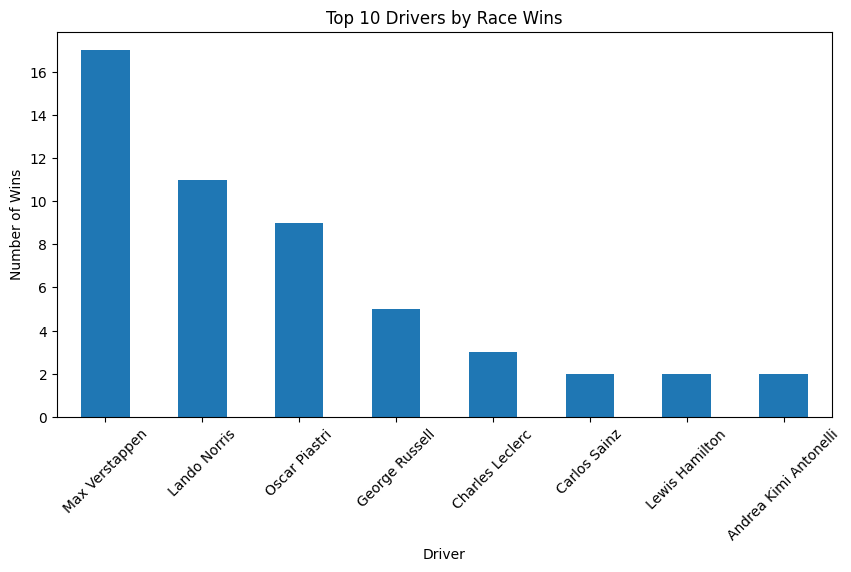

In [70]:
# Get only race winners
winners = race_results[race_results["position"] == 1]

# Count wins for each driver
top_drivers = winners["driver_name"].value_counts().head(10)

# Plot
plt.figure(figsize=(10,5))
top_drivers.plot(kind="bar")

plt.title("Top 10 Drivers by Race Wins")
plt.xlabel("Driver")
plt.ylabel("Number of Wins")

plt.xticks(rotation=45)
plt.show()

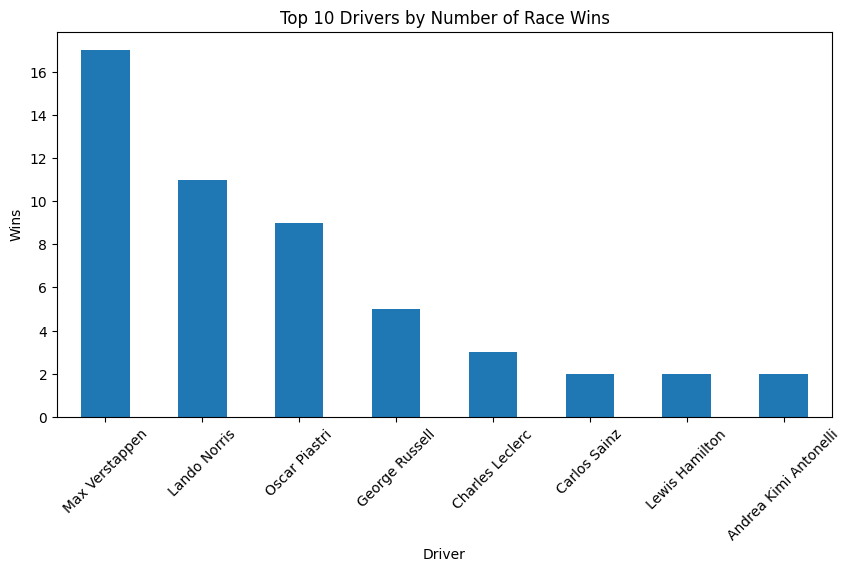

In [71]:
# Select only race winners
winners = race_results[race_results["position"] == 1]

# Count wins
top_drivers = winners["driver_name"].value_counts().head(10)

# Plot
plt.figure(figsize=(10,5))
top_drivers.plot(kind="bar")

plt.title("Top 10 Drivers by Number of Race Wins")
plt.xlabel("Driver")
plt.ylabel("Wins")

plt.xticks(rotation=45)

plt.show()

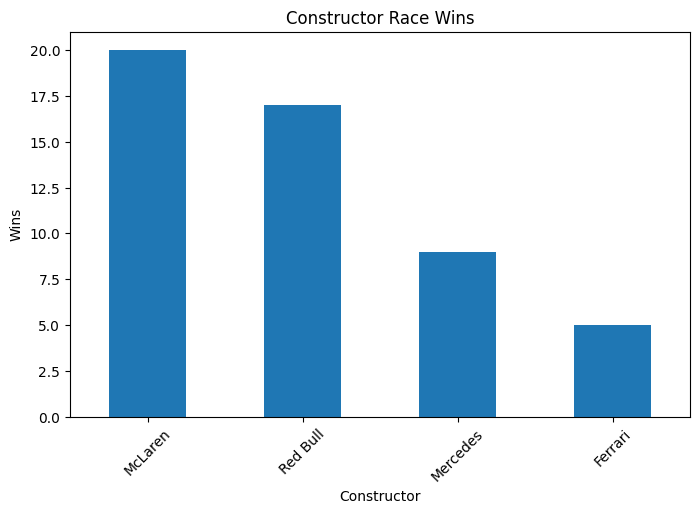

In [72]:
# Count constructor wins
top_teams = winners["constructor"].value_counts()

plt.figure(figsize=(8,5))
top_teams.plot(kind="bar")

plt.title("Constructor Race Wins")
plt.xlabel("Constructor")
plt.ylabel("Wins")

plt.xticks(rotation=45)

plt.show()

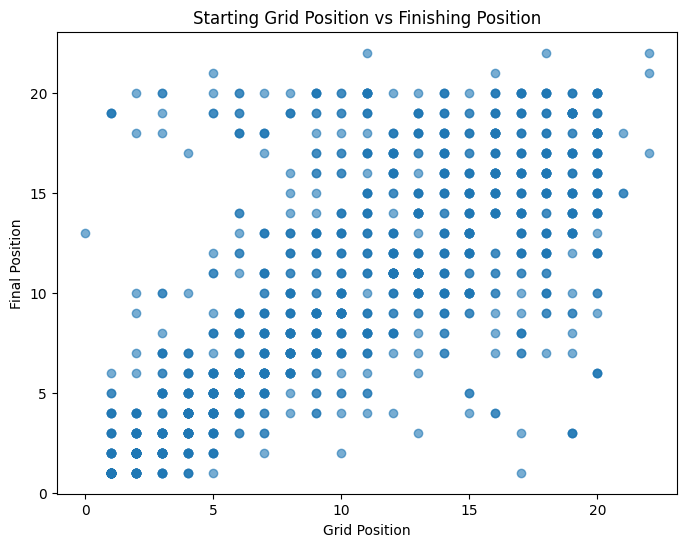

In [73]:
#Average Grid Position vs Finish Position
plt.figure(figsize=(8,6))
plt.scatter(
    race_results["grid_pos"],
    race_results["position"],
    alpha=0.6
)

plt.title("Starting Grid Position vs Finishing Position")

plt.xlabel("Grid Position")

plt.ylabel("Final Position")

plt.show()

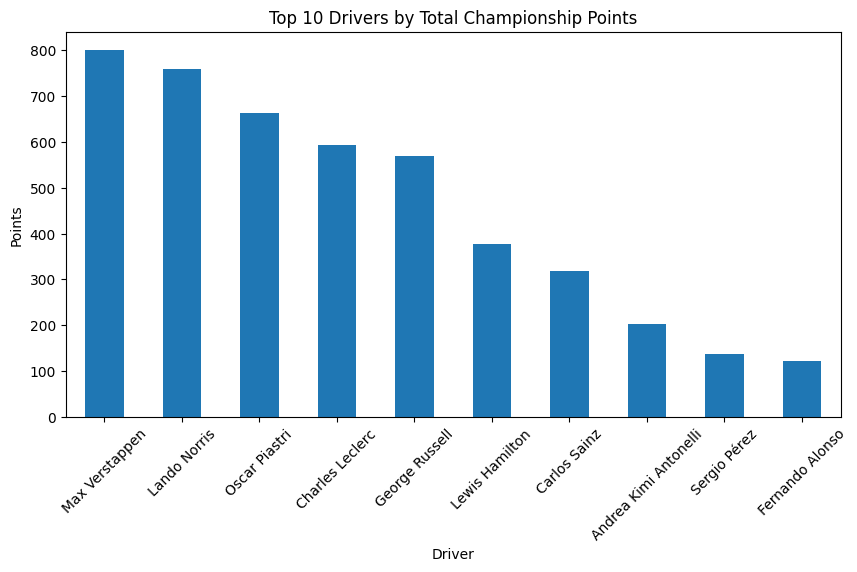

In [74]:
#Top 10 Drivers by Total Points

driver_points = race_results.groupby("driver_name")["points"].sum()

driver_points = driver_points.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))

driver_points.plot(kind="bar")

plt.title("Top 10 Drivers by Total Championship Points")

plt.xlabel("Driver")

plt.ylabel("Points")

plt.xticks(rotation=45)

plt.show()

In [75]:
# Select the features (inputs)
X = race_results[[
    "season",
    "round",
    "driver_name",
    "constructor",
    "grid_pos"
]].copy()
# Select the target (output)

y = race_results["Top3"]

In [76]:
X.head()

,season,round,driver_name,constructor,grid_pos
0,2024,1,Max Verstappen,Red Bull,1
1,2024,1,Sergio Pérez,Red Bull,5
2,2024,1,Carlos Sainz,Ferrari,4
3,2024,1,Charles Leclerc,Ferrari,2
4,2024,1,George Russell,Mercedes,3


In [77]:
from sklearn.preprocessing import LabelEncoder

In [78]:
driver_encoder = LabelEncoder()
constructor_encoder = LabelEncoder()

X["driver_name"] = driver_encoder.fit_transform(X["driver_name"])
X["constructor"] = constructor_encoder.fit_transform(X["constructor"])

In [79]:
X.head()

,season,round,driver_name,constructor,grid_pos
0,2024,1,20,9,1
1,2024,1,25,9,5
2,2024,1,3,4,4
3,2024,1,4,4,2
4,2024,1,10,7,3


In [80]:
from sklearn.model_selection import train_test_split

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [81]:
print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (819, 5)
Testing Data: (205, 5)


In [82]:
from sklearn.linear_model import LogisticRegression

# Create model
model = LogisticRegression(max_iter=1000)

# Train model
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [83]:
predictions = model.predict(X_test)

In [84]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.9073170731707317


In [85]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.96      0.93      0.94       175
           1       0.66      0.77      0.71        30

    accuracy                           0.91       205
   macro avg       0.81      0.85      0.83       205
weighted avg       0.91      0.91      0.91       205



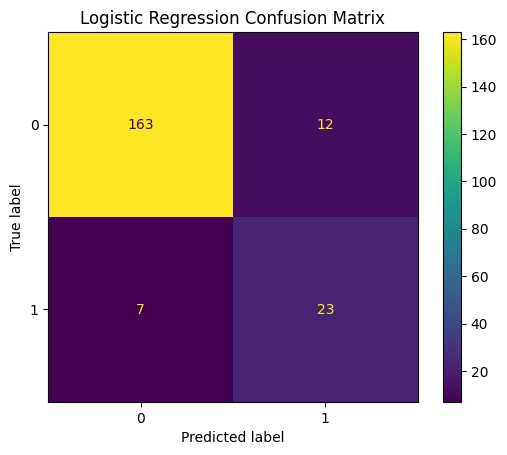

In [86]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, predictions)

plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [87]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [88]:
rf_predictions = rf_model.predict(X_test)

In [89]:
print("Accuracy:", accuracy_score(y_test, rf_predictions))

Accuracy: 0.8731707317073171


In [90]:
print(classification_report(y_test, rf_predictions))

              precision    recall  f1-score   support

           0       0.93      0.92      0.93       175
           1       0.56      0.60      0.58        30

    accuracy                           0.87       205
   macro avg       0.75      0.76      0.75       205
weighted avg       0.88      0.87      0.87       205



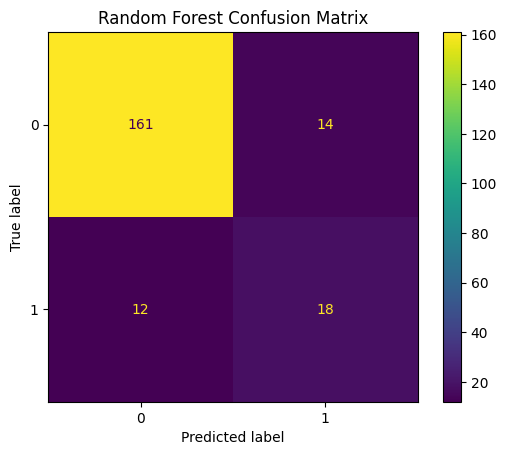

In [91]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_predictions
)

plt.title("Random Forest Confusion Matrix")

plt.show()

In [92]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_predictions = dt_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, dt_predictions))

print(classification_report(y_test, dt_predictions))

Accuracy: 0.824390243902439
              precision    recall  f1-score   support

           0       0.89      0.90      0.90       175
           1       0.39      0.37      0.38        30

    accuracy                           0.82       205
   macro avg       0.64      0.63      0.64       205
weighted avg       0.82      0.82      0.82       205



In [93]:
# Feature Importance

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

       Feature  Importance
4     grid_pos    0.544713
1        round    0.217896
2  driver_name    0.101008
3  constructor    0.094886
0       season    0.041497


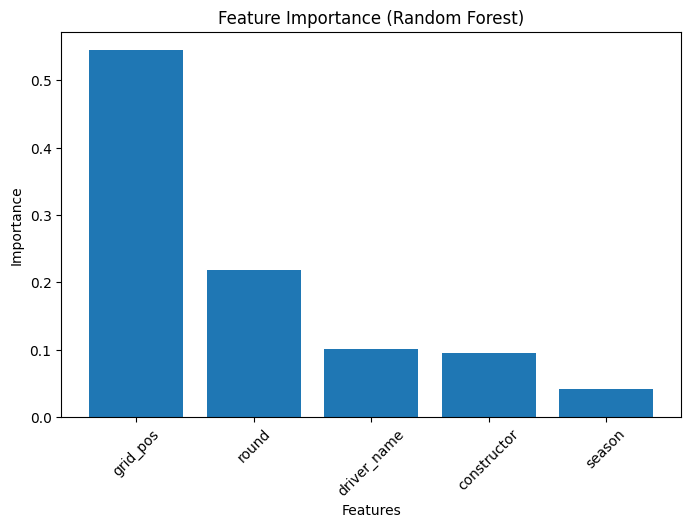

In [94]:
plt.figure(figsize=(8,5))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Feature Importance (Random Forest)")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.xticks(rotation=45)

plt.show()

In [100]:
import difflib
import pandas as pd

print("=" * 60)
print("🏎️        FORMULA 1 AI TOP 3 PREDICTOR")
print("=" * 60)

# ==========================
# DRIVER INPUT
# ==========================

driver = input("\n👤 Enter Driver Name: ").strip()

driver_dict = {d.lower(): d for d in driver_encoder.classes_}

if driver.lower() in driver_dict:
    driver = driver_dict[driver.lower()]
else:
    suggestion = difflib.get_close_matches(
        driver,
        driver_encoder.classes_,
        n=1,
        cutoff=0.55
    )

    if suggestion:
        choice = input(
            f"\n❌ Driver '{driver}' not found.\n"
            f"💡 Did you mean '{suggestion[0]}'? (Y/N): "
        ).strip().lower()

        if choice in ["y", "yes"]:
            driver = suggestion[0]
            print(f"✅ Using Driver: {driver}")
        else:
            print("❌ Prediction Cancelled.")
            raise SystemExit
    else:
        print("❌ No similar driver found.")
        raise SystemExit

# ==========================
# CONSTRUCTOR INPUT
# ==========================

constructor = input("\n🏁 Enter Constructor: ").strip()

constructor_dict = {c.lower(): c for c in constructor_encoder.classes_}

if constructor.lower() in constructor_dict:
    constructor = constructor_dict[constructor.lower()]
else:
    suggestion = difflib.get_close_matches(
        constructor,
        constructor_encoder.classes_,
        n=1,
        cutoff=0.55
    )

    if suggestion:
        choice = input(
            f"\n❌ Constructor '{constructor}' not found.\n"
            f"💡 Did you mean '{suggestion[0]}'? (Y/N): "
        ).strip().lower()

        if choice in ["y", "yes"]:
            constructor = suggestion[0]
            print(f"✅ Using Constructor: {constructor}")
        else:
            print("❌ Prediction Cancelled.")
            raise SystemExit
    else:
        print("❌ No similar constructor found.")
        raise SystemExit

# ==========================
# SEASON INPUT
# ==========================

while True:
    try:
        season = int(input("\nEnter Season (2024-2026): "))

        if season in [2024, 2025, 2026]:
            break

        print("❌ Please enter only 2024, 2025 or 2026.")

    except ValueError:
        print("❌ Please enter a valid number.")

# ==========================
# ROUND INPUT
# ==========================

available_rounds = sorted(race_results["round"].unique())

while True:
    try:
        round_num = int(input("\n Enter Race Round: "))

        if round_num in available_rounds:
            break

        print(f"❌ Round must be between {min(available_rounds)} and {max(available_rounds)}.")

    except ValueError:
        print("❌ Please enter a valid number.")

# ==========================
# GRID POSITION
# ==========================

while True:
    try:
        grid = int(input("\n Enter Grid Position (1-20): "))

        if 1 <= grid <= 20:
            break

        print("❌ Grid Position must be between 1 and 20.")

    except ValueError:
        print("❌ Please enter a valid number.")

# ==========================
# ENCODE INPUT
# ==========================

driver_encoded = driver_encoder.transform([driver])[0]
constructor_encoded = constructor_encoder.transform([constructor])[0]

input_data = pd.DataFrame({
    "season": [season],
    "round": [round_num],
    "driver_name": [driver_encoded],
    "constructor": [constructor_encoded],
    "grid_pos": [grid]
})

# ==========================
# PREDICT
# ==========================

prediction = model.predict(input_data)[0]
probability = model.predict_proba(input_data)[0]

# ==========================
# RESULT
# ==========================

print("\n")
print("=" * 60)
print("             AI PREDICTION RESULT")
print("=" * 60)

print(f"👤 Driver        : {driver}")
print(f"🏁 Constructor   : {constructor}")
print(f"📅 Season        : {season}")
print(f"🏎️ Race Round    : {round_num}")
print(f"🚦 Grid Position : {grid}")

print("-" * 60)

if prediction == 1:
    print("Prediction: TOP 3 Finish")
else:
    print("Prediction: Outside TOP 3")

print()

print(f"Probability of TOP 3          : {probability[1]*100:.2f}%")
print(f"Probability of Outside TOP 3  : {probability[0]*100:.2f}%")

print("=" * 60)
print("Prediction Complete!")
print("=" * 60)

🏎️        FORMULA 1 AI TOP 3 PREDICTOR

👤 Enter Driver Name: george russell

🏁 Enter Constructor: mercedes

Enter Season (2024-2026): 2026

 Enter Race Round: 5

 Enter Grid Position (1-20): 3


             AI PREDICTION RESULT
👤 Driver        : George Russell
🏁 Constructor   : Mercedes
📅 Season        : 2026
🏎️ Race Round    : 5
🚦 Grid Position : 3
------------------------------------------------------------
Prediction: TOP 3 Finish

Probability of TOP 3          : 54.12%
Probability of Outside TOP 3  : 45.88%
Prediction Complete!
